In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_data.csv")

df

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47923,36484665,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9,4.262680
47924,36485057,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36,3.713572
47925,36485431,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27,4.753590
47926,36485609,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2,4.025352


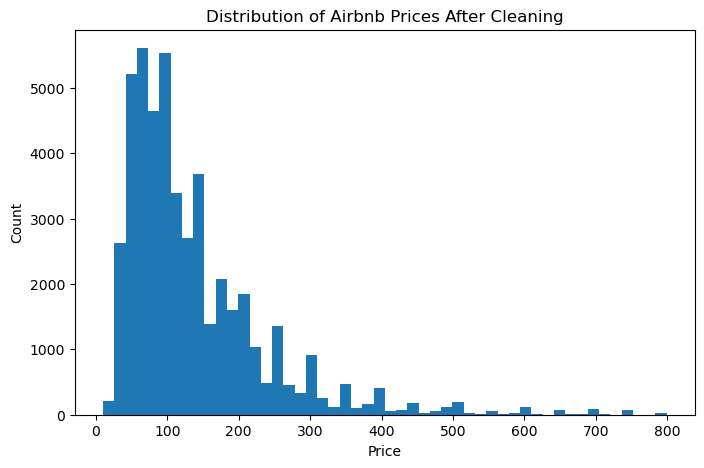

In [2]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Airbnb Prices After Cleaning")
plt.show()

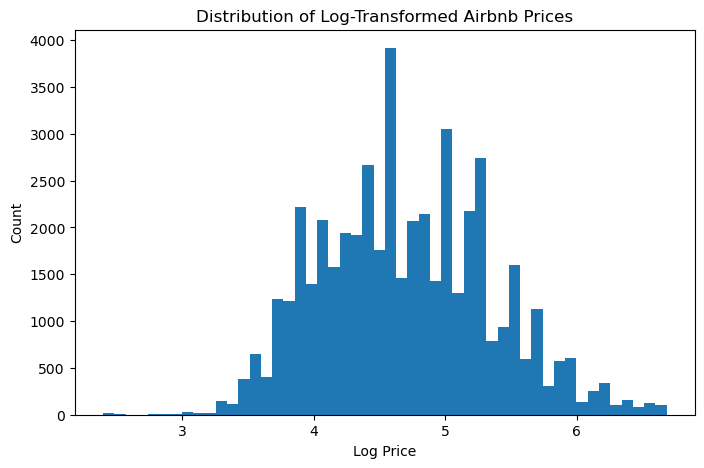

In [3]:
plt.figure(figsize=(8, 5))
plt.hist(df["log_price"], bins=50)
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.title("Distribution of Log-Transformed Airbnb Prices")
plt.show()

In [4]:
df.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False)

neighbourhood_group
Manhattan        149.0
Brooklyn          90.0
Queens            75.0
Staten Island     75.0
Bronx             65.0
Name: price, dtype: float64

In [5]:
df.groupby("room_type")["price"].median().sort_values(ascending=False)

room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: price, dtype: float64

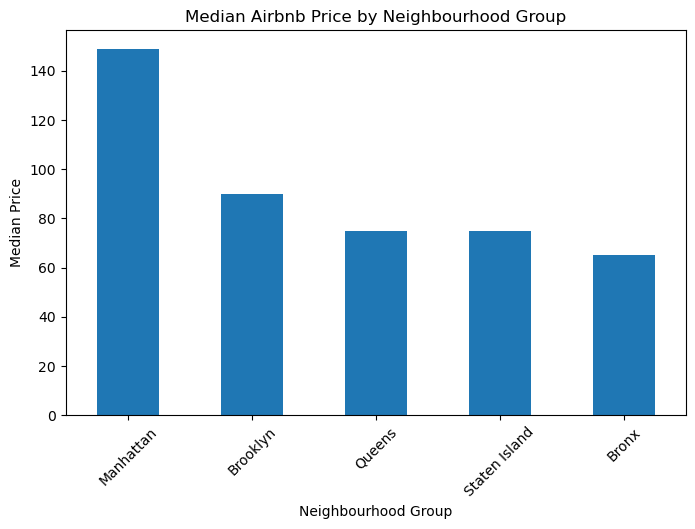

In [6]:
median_price_area = df.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
median_price_area.plot(kind="bar")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Median Price")
plt.title("Median Airbnb Price by Neighbourhood Group")
plt.xticks(rotation=45)
plt.show()

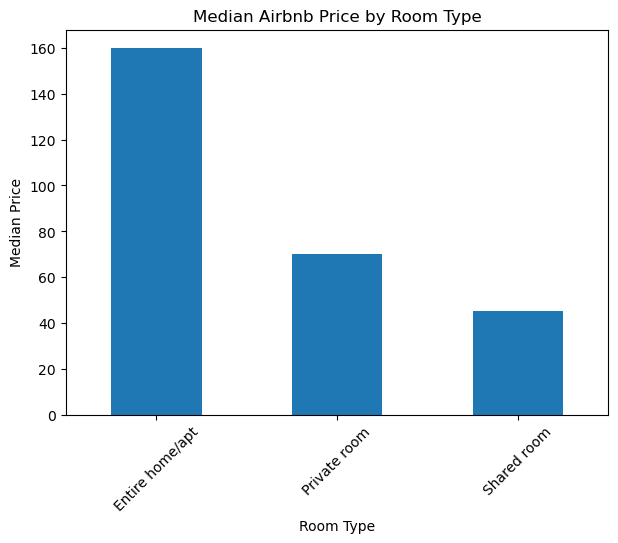

In [7]:
median_price_room = df.groupby("room_type")["price"].median().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
median_price_room.plot(kind="bar")
plt.xlabel("Room Type")
plt.ylabel("Median Price")
plt.title("Median Airbnb Price by Room Type")
plt.xticks(rotation=45)
plt.show()

In [8]:
price_by_area_room = df.pivot_table(
    values="price",
    index="neighbourhood_group",
    columns="room_type",
    aggfunc="median"
)

price_by_area_room

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.0,53.5,40.0
Brooklyn,145.0,65.0,36.0
Manhattan,190.0,90.0,69.0
Queens,120.0,60.0,37.0
Staten Island,100.0,50.0,30.0


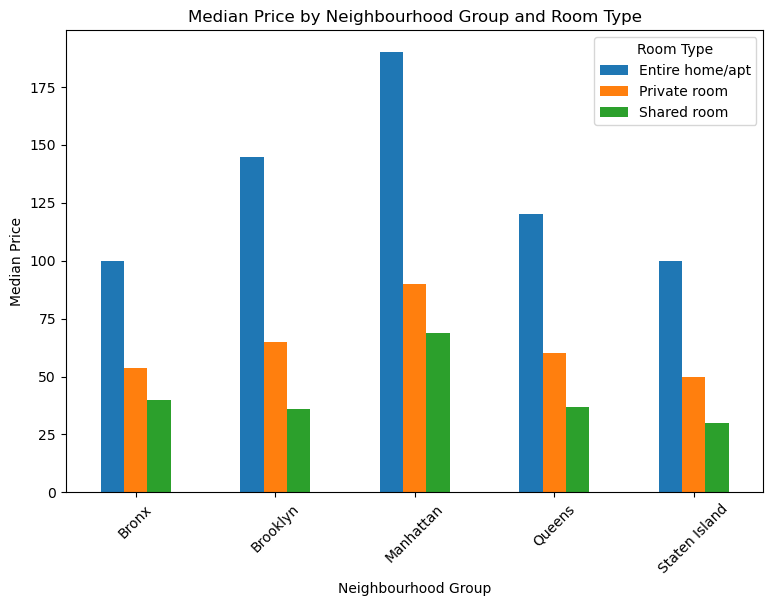

In [9]:
price_by_area_room.plot(kind="bar", figsize=(9, 6))
plt.xlabel("Neighbourhood Group")
plt.ylabel("Median Price")
plt.title("Median Price by Neighbourhood Group and Room Type")
plt.xticks(rotation=45)
plt.legend(title="Room Type")
plt.show()

In [13]:
numeric_cols = [
    "log_price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude"
]

corr = df[numeric_cols].corr()

corr["log_price"].sort_values(ascending=False)

log_price                         1.000000
calculated_host_listings_count    0.146281
availability_365                  0.086515
latitude                          0.082946
minimum_nights                    0.049865
number_of_reviews                -0.033697
reviews_per_month                -0.050815
longitude                        -0.331327
Name: log_price, dtype: float64

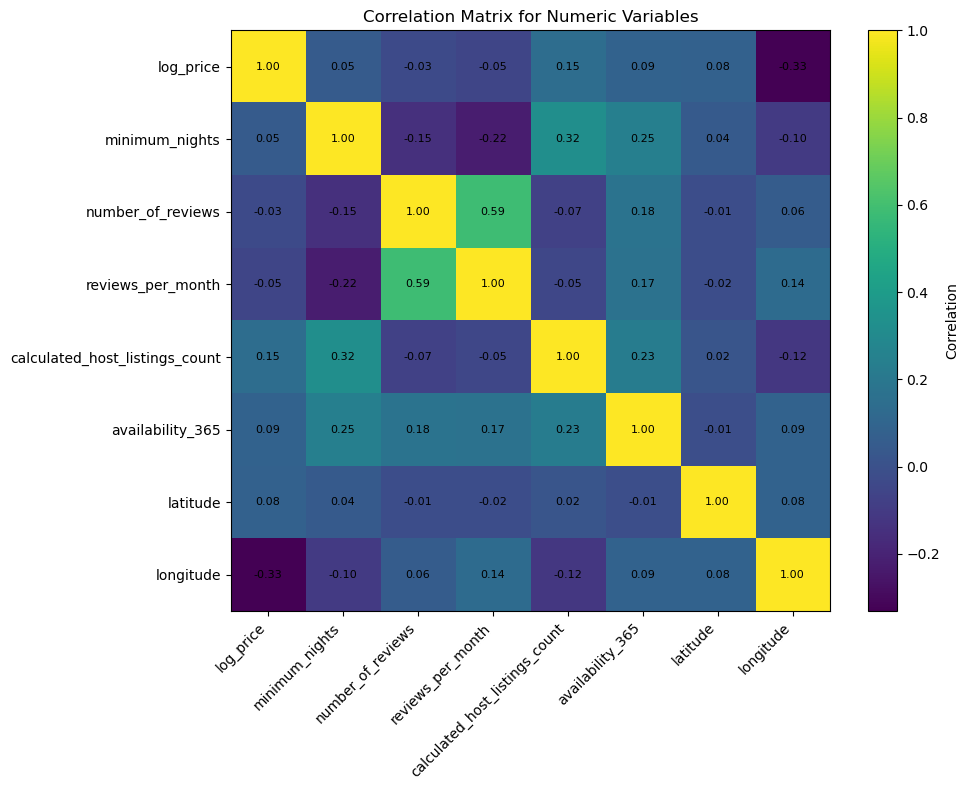

In [18]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Matrix for Numeric Variables")
plt.tight_layout()
plt.show()

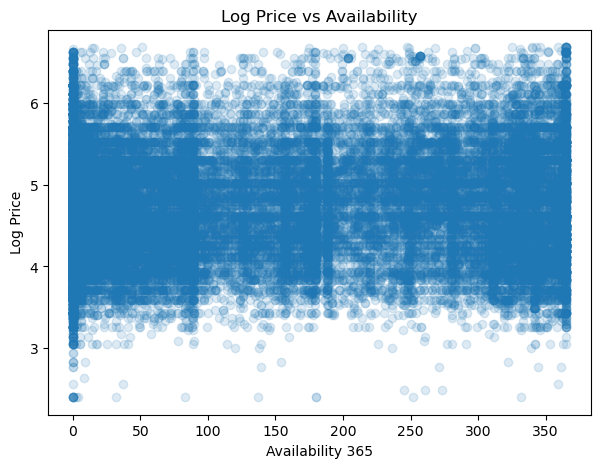

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(df["availability_365"], df["log_price"], alpha=0.15)
plt.xlabel("Availability 365")
plt.ylabel("Log Price")
plt.title("Log Price vs Availability")
plt.show()

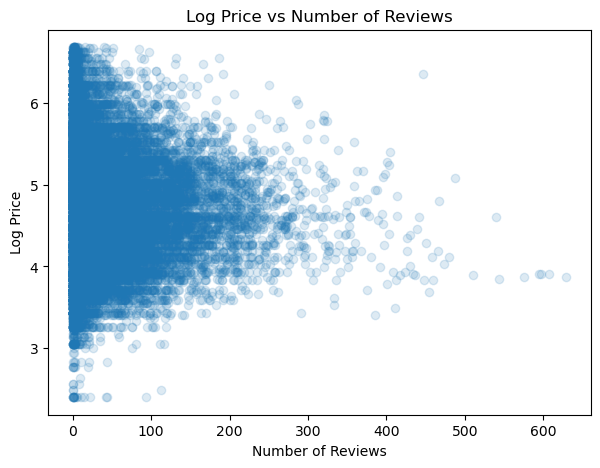

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(df["number_of_reviews"], df["log_price"], alpha=0.15)
plt.xlabel("Number of Reviews")
plt.ylabel("Log Price")
plt.title("Log Price vs Number of Reviews")
plt.show()

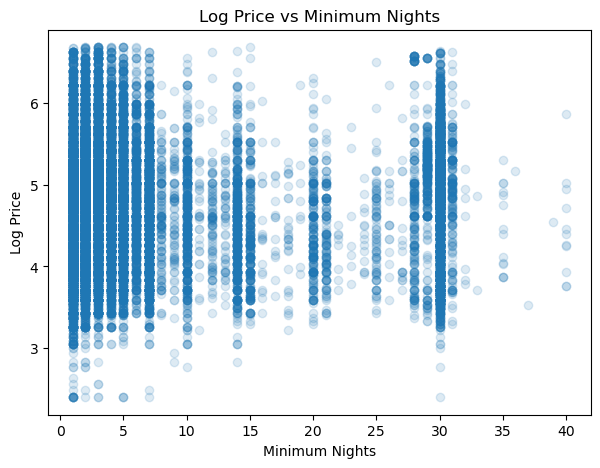

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(df["minimum_nights"], df["log_price"], alpha=0.15)
plt.xlabel("Minimum Nights")
plt.ylabel("Log Price")
plt.title("Log Price vs Minimum Nights")
plt.show()

In [19]:
cluster_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "log_price"
]

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [21]:
cluster_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "log_price"
]

X_cluster = df[cluster_features].copy()

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [22]:
sample_idx = np.random.RandomState(42).choice(
    X_cluster_scaled.shape[0],
    size=5000,
    replace=False
)

X_sample = X_cluster_scaled[sample_idx]

In [23]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels))

k_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias,
    "Silhouette": silhouettes
})

k_results

,K,Inertia,Silhouette
0,2,33899.244556,0.381314
1,3,28360.426430,0.275764
2,4,24413.839259,0.290838
3,5,21529.133816,0.196410
4,6,19391.458529,0.197798
5,7,17689.168364,0.208054
6,8,16020.477980,0.220729


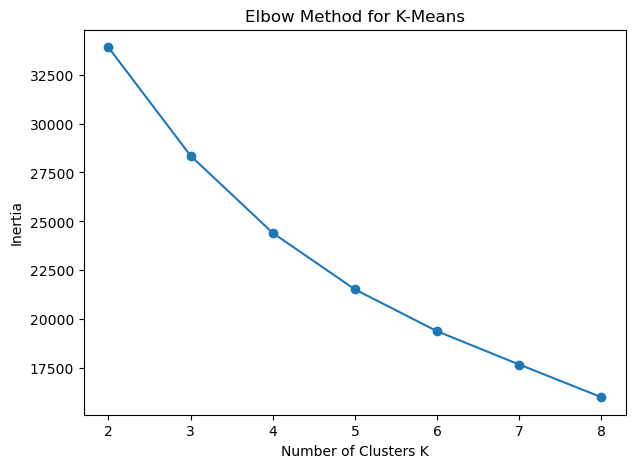

In [24]:
plt.figure(figsize=(7, 5))
plt.plot(k_results["K"], k_results["Inertia"], marker="o")
plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

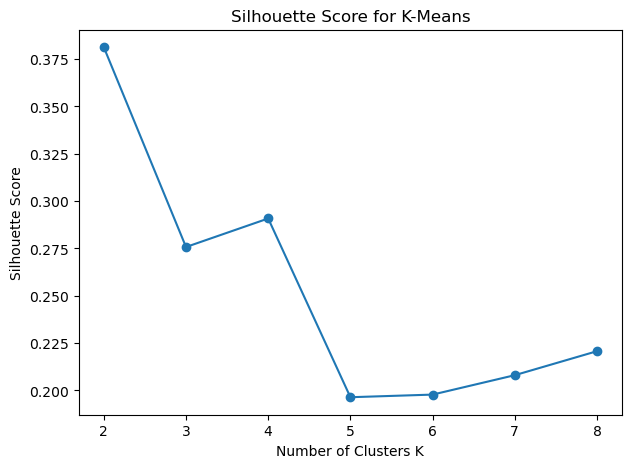

In [25]:
plt.figure(figsize=(7, 5))
plt.plot(k_results["K"], k_results["Silhouette"], marker="o")
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.show()

In [26]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

df["cluster"] = kmeans_final.fit_predict(X_cluster_scaled)

In [27]:
df["cluster"].value_counts().sort_index()

cluster
0    10353
1    32272
2     4752
3      551
Name: count, dtype: int64

In [28]:
cluster_summary = df.groupby("cluster")[[
    "price",
    "log_price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude"
]].mean()

cluster_summary

,price,log_price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,latitude,longitude
cluster,,,,,,,,,
0,119.303680,4.597347,2.147783,78.397759,3.356741,2.321356,185.359026,40.726197,-73.930240
1,140.331030,4.733528,3.236118,8.599250,0.505728,1.788888,69.539973,40.728585,-73.956594
2,143.679714,4.737805,28.594697,7.999790,0.316206,21.766835,215.550926,40.736285,-73.961096
3,273.617060,5.554337,20.096189,2.377495,0.732486,288.379310,282.640653,40.729791,-73.996984


In [29]:
pd.crosstab(df["cluster"], df["neighbourhood_group"], normalize="index")

neighbourhood_group,Bronx,Brooklyn,Manhattan,Queens,Staten Island
cluster,,,,,
0,0.042693,0.409736,0.320100,0.219550,0.007920
1,0.018313,0.437128,0.445773,0.090543,0.008242
2,0.008838,0.309343,0.588384,0.089226,0.004209
3,0.000000,0.003630,0.996370,0.000000,0.000000


In [30]:
pd.crosstab(df["cluster"], df["room_type"], normalize="index")

room_type,Entire home/apt,Private room,Shared room
cluster,,,
0,0.464117,0.508258,0.027625
1,0.503378,0.473940,0.022682
2,0.655303,0.319234,0.025463
3,0.985481,0.014519,0.000000


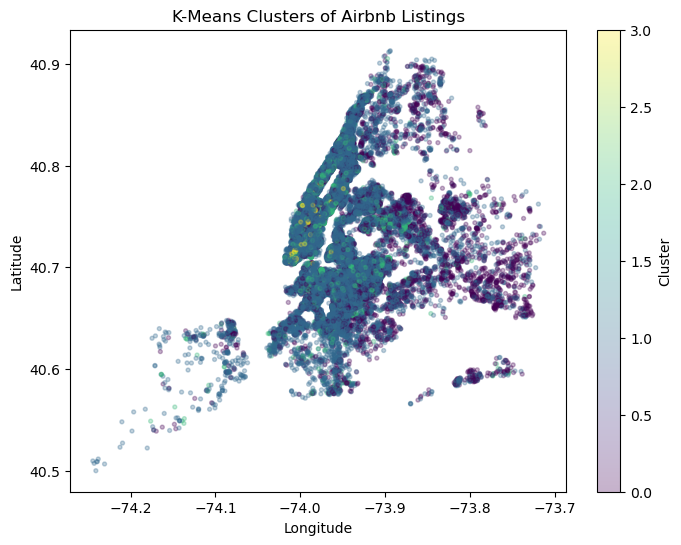

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["cluster"],
    alpha=0.3,
    s=8
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clusters of Airbnb Listings")
plt.colorbar(label="Cluster")
plt.show()

In [32]:
df["cluster"].value_counts().sort_index()

cluster
0    10353
1    32272
2     4752
3      551
Name: count, dtype: int64

In [33]:
cluster_summary = df.groupby("cluster")[[
    "price",
    "log_price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude"
]].mean()

cluster_summary

,price,log_price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,latitude,longitude
cluster,,,,,,,,,
0,119.303680,4.597347,2.147783,78.397759,3.356741,2.321356,185.359026,40.726197,-73.930240
1,140.331030,4.733528,3.236118,8.599250,0.505728,1.788888,69.539973,40.728585,-73.956594
2,143.679714,4.737805,28.594697,7.999790,0.316206,21.766835,215.550926,40.736285,-73.961096
3,273.617060,5.554337,20.096189,2.377495,0.732486,288.379310,282.640653,40.729791,-73.996984
